In [ ]:
# read final_df from csv file
import pandas as pd
df_final = pd.read_csv(r'd:/Github/Data/final_material_data_20250114.csv')
# exclude historical buildings before 1930
df_final_wt_hb = df_final[df_final['year of construction of the building yyyy'] >= 1930]
# # exclude buildings newer than 2020
# df_final_wt_hb = df_final_wt_hb[df_final_wt_hb['year of construction of the building yyyy'] <= 2020]
# remove bathtubs for all buildings except residential buildings
df_final_wt_hb = df_final_wt_hb[~((df_final_wt_hb['component'] == 'bathtub') & (df_final_wt_hb['building class'] != 'residential'))]
# add stainless steel and steel to be the same material
df_final_wt_hb['material'] = df_final_wt_hb['material'].replace({'stainless steel': 'steel'})
# Define component lifespan
component_lifespan = {
    'electrical cable': 50,
    'boiler': 35,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 35,
    'heat pump': 30,
    'toilet': 50,
    'shower': 30,
    'sink': 50,
    'bathtub': 50
}

# Add end-of-life year for each component
df_final_wt_hb['end_of_life_year'] = df_final_wt_hb['year of construction of the building yyyy'] + df_final_wt_hb['component'].map(component_lifespan)

# Group by decade of end-of-life year and material type, summing material weights
df_final_wt_hb['end_of_life_decade'] = (df_final_wt_hb['end_of_life_year'] // 10) * 10
material_availability = df_final_wt_hb.groupby(['end_of_life_decade', 'material'])['material_weight'].sum().unstack(fill_value=0)

# **Regression-based Fitting Model**

In [ ]:
# Latin Hypercube Sampling to identify the best path for each component
from SALib.sample import latin
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ 1. 定义组件数据
components = pd.DataFrame([
    ['Electrical Cable', 5, 5, 5, 1, 1, 1, 5],
    ['Boiler', 5, 5, 5, 3, 3, 4, 5],
    ['Water Pipe', 5, 1, 5, 1, 1, 1, 1],
    ['Air Duct', 1, 1, 5, 1, 1, 5, 5],
    ['Radiator', 1, 1, 5, 3, 3, 5, 5],
    ['Heat Pump', 5, 5, 5, 3, 3, 5, 5],
    ['Toilet', 5, 5, 1, 4, 4, 3, 1],
    ['Sink', 5, 5, 1, 4, 4, 3, 1],
    ['Shower', 5, 5, 1, 4, 4, 3, 1],
    ['Bathtub', 5, 5, 1, 4, 4, 3, 1]
], columns=[
    'Component', 'Compatibility', 'Regulation', 'Disposal',
    'Lifespan', 'Disassembly', 'CostEffective', 'MaterialContent'
])

# ✅ 2. 定义权重空间（15个参数）
param_bounds = [
    ('a1', 1, 3), ('a2', 1, 3), ('a3', 1, 3), ('a4', 1, 3), ('a5', 1, 3),
    ('b1', 1, 3), ('b2', 1, 3), ('b3', 1, 3), ('b4', 1, 3),
    ('g1', 1, 3), ('g2', 1, 3),
    ('d1', 0.5, 2), ('d2', 0.5, 2), ('d3', 0.5, 2)
]

problem = {
    'num_vars': len(param_bounds),
    'names': [p[0] for p in param_bounds],
    'bounds': [[p[1], p[2]] for p in param_bounds]
}

# ✅ 3. Latin Hypercube Sampling
n_samples = 300
lhs_samples = latin.sample(problem, N=n_samples)
lhs_param_samples = pd.DataFrame(lhs_samples, columns=problem['names'])

# ✅ 4. 模型运行：计算最优路径
lhs_results = []

for i, weights in lhs_param_samples.iterrows():
    for _, row in components.iterrows():
        RS = weights['a1'] * row['Compatibility'] + weights['a2'] * row['Regulation'] + \
             weights['a3'] * row['Disposal'] + weights['a4'] * row['Lifespan'] + weights['a5'] * row['Disassembly']
        RF = weights['b1'] * row['Lifespan'] + weights['b2'] * row['Disassembly'] + \
             weights['b3'] * row['Compatibility'] + weights['b4'] * row['Regulation']
        RC = weights['g1'] * row['MaterialContent'] + weights['g2'] * row['CostEffective']
        DS = weights['d1'] * row['Disposal'] + weights['d2'] * row['Compatibility'] + weights['d3'] * row['Lifespan']

        scores = {'Reuse': RS, 'Refurbish': RF, 'Recycle': RC, 'Disposal': DS}
        best_path = max(scores, key=scores.get)

        lhs_results.append({
            'Component': row['Component'],
            'Scenario_ID': i,
            'BestPath': best_path
        })

# ✅ 5. 汇总结果
lhs_df_results = pd.DataFrame(lhs_results)
lhs_summary = lhs_df_results.groupby(['Component', 'BestPath']).size().unstack(fill_value=0)
lhs_summary_percent = lhs_summary.div(lhs_summary.sum(axis=1), axis=0) * 100

print(lhs_summary_percent.round(1))

# # ✅ 6. 模拟敏感性分析数据 + 绘制4路径热力图
# paths = ['Reuse', 'Refurbish', 'Recycle', 'Disposal']
# parameters = problem['names']

# np.random.seed(42)
# sensitivity_all = {}
# for path in paths:
#     s1 = np.random.rand(len(parameters)) * 0.05
#     st = np.random.rand(len(parameters)) * 0.1
#     if path == 'Reuse':
#         st[0:5] += 0.3  # a1–a5
#     elif path == 'Refurbish':
#         st[5:9] += 0.3  # b1–b4
#     elif path == 'Recycle':
#         st[9:11] += 0.3  # g1–g2
#     elif path == 'Disposal':
#         st[11:] += 0.3  # d1–d3
#     sensitivity_all[path] = pd.DataFrame({'S1': s1, 'ST': st}, index=parameters)

# # 画图
# fig, axes = plt.subplots(1, 4, figsize=(20, 8), sharey=True)
# for i, path in enumerate(paths):
#     ax = axes[i]
#     sns.heatmap(sensitivity_all[path], annot=True, cmap="YlOrRd", cbar=i==3,
#                 fmt=".2f", ax=ax, vmin=0, vmax=0.5)
#     ax.set_title(f"{path} Path")
#     ax.set_ylabel('' if i > 0 else 'Parameter')

# plt.suptitle("Sensitivity Indices Heatmaps for Each Pathway", fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()


BestPath          Disposal  Recycle  Refurbish  Reuse
Component                                            
Air Duct               0.0     63.7        0.0   36.3
Bathtub                0.0      0.0       40.0   60.0
Boiler                 0.0      0.0        8.0   92.0
Electrical Cable       0.0      0.0        5.3   94.7
Heat Pump              0.0      0.0        8.0   92.0
Radiator               0.0     15.3        0.7   84.0
Shower                 0.0      0.0       40.0   60.0
Sink                   0.0      0.0       40.0   60.0
Toilet                 0.0      0.0       40.0   60.0
Water Pipe             0.7      0.0        3.3   96.0


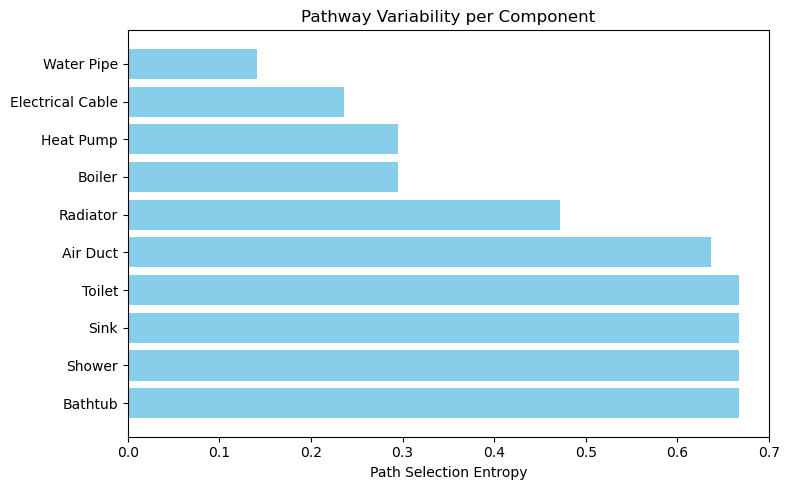

In [ ]:
# # ✅ 7. 绘制路径选择熵图
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# 汇总各组件各路径频率
lhs_summary = lhs_df_results.groupby(['Component', 'BestPath']).size().unstack(fill_value=0)
lhs_summary_percent = lhs_summary.div(lhs_summary.sum(axis=1), axis=0) * 100

# 计算每个组件路径选择的熵（衡量路径分布的离散程度）
lhs_entropy = lhs_summary_percent.apply(lambda row: entropy(row / 100), axis=1)
entropy_df = pd.DataFrame({'Component': lhs_entropy.index, 'Path_Entropy': lhs_entropy.values})
entropy_df.sort_values('Path_Entropy', ascending=False, inplace=True)

# 绘制条形图
plt.figure(figsize=(8, 5))
plt.barh(entropy_df['Component'], entropy_df['Path_Entropy'], color='skyblue')
plt.xlabel('Path Selection Entropy')
plt.title('Pathway Variability per Component')
plt.tight_layout()
plt.show()


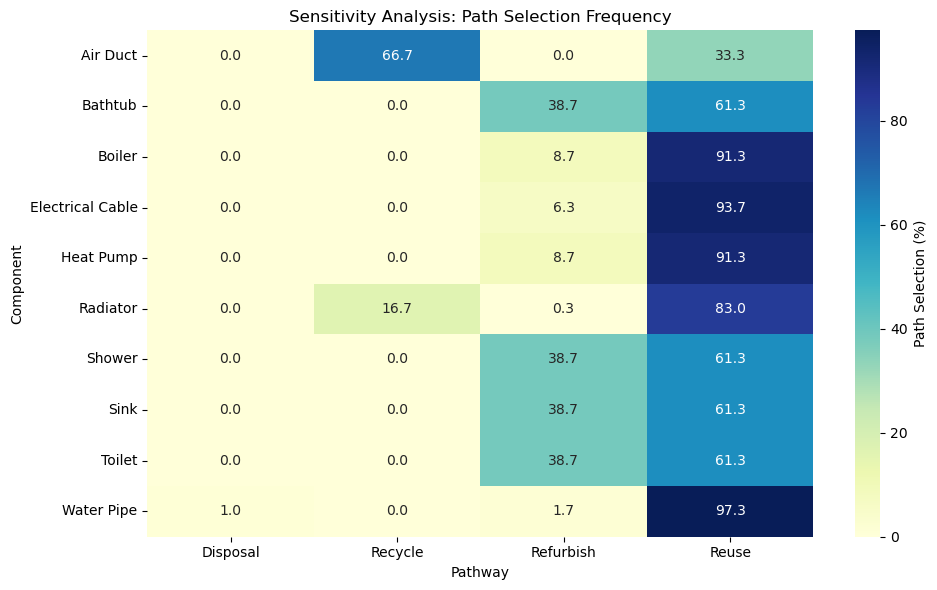

In [ ]:
# ✅ 直接使用 lhs_summary_percent 画热图
plt.figure(figsize=(10, 6))
sns.heatmap(lhs_summary_percent, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Path Selection (%)'})
plt.title("Sensitivity Analysis: Path Selection Frequency")
plt.ylabel("Component")
plt.xlabel("Pathway")
plt.tight_layout()
plt.show()

In [ ]:
# inverse modeling to estimate the weights for the model based on current practice
# # Full code to reconstruct the entire modeling process as a standalone script

# Step 1: Imports
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge

# Step 2: Data definition
# Component features
feature_data = {
    "Component": [
        "Electrical Cable", "Boiler", "Water Pipe", "Air Duct", "Radiator",
        "Heat Pump", "Toilet", "Sink", "Shower", "Bathtub"
    ],
    "Material": [
        "Copper", "Steel", "PEX", "Aluminum", "Steel",
        "Steel", "Ceramic", "Ceramic", "Ceramic", "Ceramic"
    ],
    "Technological Compatibility": [5, 5, 5, 1, 1, 5, 5, 5, 5, 5],
    "Regulatory Compliance": [5, 5, 1, 1, 1, 5, 5, 5, 5, 5],
    "Disposal and Energy Recovery": [5, 5, 5, 5, 5, 5, 1, 1, 1, 1],
    "Lifespan Qualification": [1, 3, 1, 1, 3, 3, 4, 4, 4, 4],
    "New/Good Condition/Disassembly Easiness": [1, 3, 1, 1, 3, 3, 4, 4, 4, 4],
    "Cost-Effective": [1, 4, 1, 5, 5, 5, 3, 3, 3, 3],
    "Metal Content": [5, 5, 1, 5, 5, 5, 1, 1, 1, 1]
}
df_features = pd.DataFrame(feature_data)

# Current practice percentage
pathway_data = {
    "Reuse": [0.1, 0.05, 0.2, 0.15, 0.05, 0.05, 0.1, 0.1, 0.05, 0.05],
    "Recycle": [0.4, 0.5, 0.3, 0.45, 0.25, 0.55, 0.2, 0.2, 0.15, 0.15],
    "Refurbish": [0.1, 0.1, 0.1, 0.15, 0.05, 0.15, 0.05, 0.05, 0.05, 0.05],
    "Disposal": [0.4, 0.35, 0.4, 0.25, 0.65, 0.25, 0.65, 0.65, 0.75, 0.75]
}
df_pathways = pd.DataFrame(pathway_data)

# Step 3: Feature normalization
features = [
    "Technological Compatibility", "Regulatory Compliance", "Disposal and Energy Recovery",
    "Lifespan Qualification", "New/Good Condition/Disassembly Easiness",
    "Cost-Effective", "Metal Content"
]
scaler = MinMaxScaler()
X_features = scaler.fit_transform(df_features[features])

# Step 4: Fit Ridge regression model to estimate weights
reg_model = Ridge(alpha=0.1)
reg_model.fit(X_features, df_pathways)

# Step 5: Extract and display the weights
weights_df = pd.DataFrame(reg_model.coef_, columns=features, index=["Reuse", "Recycle", "Refurbish", "Disposal"])
weights_df


,Technological Compatibility,Regulatory Compliance,Disposal and Energy Recovery,Lifespan Qualification,New/Good Condition/Disassembly Easiness,Cost-Effective,Metal Content
Reuse,0.016209,-0.029739,-0.011906,-0.055562,-0.055562,0.016510,-0.057854
Recycle,0.149885,0.081971,0.122482,-0.092662,-0.092662,0.221378,0.054568
Refurbish,0.041736,0.020796,0.010855,-0.051346,-0.051346,0.090233,-0.010085
Disposal,-0.207831,-0.073029,-0.121431,0.199571,0.199571,-0.328120,0.013371


In [27]:
# weight estimation based on current practice but with predefined theoretical formulas

# Step 1: Imports
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge

# Step 2: Data definition
# Component features
feature_data = {
    "Component": [
        "Electrical Cable", "Boiler", "Water Pipe", "Air Duct", "Radiator",
        "Heat Pump", "Toilet", "Sink", "Shower", "Bathtub"
    ],
    "Material": [
        "Copper", "Steel", "PEX", "Aluminum", "Steel",
        "Steel", "Ceramic", "Ceramic", "Ceramic", "Ceramic"
    ],
    "Technological Compatibility": [5, 5, 5, 1, 1, 5, 5, 5, 5, 5],
    "Regulatory Compliance": [5, 5, 1, 1, 1, 5, 5, 5, 5, 5],
    "Disposal and Energy Recovery": [5, 5, 5, 5, 5, 5, 1, 1, 1, 1],
    "Lifespan Qualification": [1, 3, 1, 1, 3, 3, 4, 4, 4, 4],
    "New/Good Condition/Disassembly Easiness": [1, 3, 1, 1, 3, 3, 4, 4, 4, 4],
    "Cost-Effective": [1, 4, 1, 5, 5, 5, 3, 3, 3, 3],
    "Metal Content": [5, 5, 1, 5, 5, 5, 1, 1, 1, 1]
}
df_features = pd.DataFrame(feature_data)

# Current practice percentage
pathway_data = {
    "Reuse": [0.1, 0.05, 0.2, 0.15, 0.05, 0.05, 0.1, 0.1, 0.05, 0.05],
    "Recycle": [0.4, 0.5, 0.3, 0.45, 0.25, 0.55, 0.2, 0.2, 0.15, 0.15],
    "Refurbish": [0.1, 0.1, 0.1, 0.15, 0.05, 0.15, 0.05, 0.05, 0.05, 0.05],
    "Disposal": [0.4, 0.35, 0.4, 0.25, 0.65, 0.25, 0.65, 0.65, 0.75, 0.75]
}
df_pathways = pd.DataFrame(pathway_data)

# Step 3: Feature normalization
features = [
    "Technological Compatibility", "Regulatory Compliance", "Disposal and Energy Recovery",
    "Lifespan Qualification", "New/Good Condition/Disassembly Easiness",
    "Cost-Effective", "Metal Content"
]
scaler = MinMaxScaler()
X_features = scaler.fit_transform(df_features[features])
X_norm = pd.DataFrame(X_features, columns=features)

# Step 4: Define theoretical formulas (feature selection per pathway)
reuse_features = ["Technological Compatibility", "Regulatory Compliance",
                  "New/Good Condition/Disassembly Easiness", "Lifespan Qualification",
                  "Disposal and Energy Recovery"]
refurbish_features = ["Lifespan Qualification", "Disposal and Energy Recovery",
                      "Cost-Effective", "Regulatory Compliance"]
recycle_features = ["Metal Content", "Cost-Effective", "Disposal and Energy Recovery"]
disposal_features = ["New/Good Condition/Disassembly Easiness", "Cost-Effective", "Lifespan Qualification"]

# Step 5: Ridge regression per pathway
def fit_pathway_model(y, X, feature_list):
    model = Ridge(alpha=0.1)
    model.fit(X[feature_list], y)
    return pd.Series(model.coef_, index=feature_list)

y_reuse = df_pathways["Reuse"]
y_refurbish = df_pathways["Refurbish"]
y_recycle = df_pathways["Recycle"]
y_disposal = df_pathways["Disposal"]

reuse_weights = fit_pathway_model(y_reuse, X_norm, reuse_features)
refurbish_weights = fit_pathway_model(y_refurbish, X_norm, refurbish_features)
recycle_weights = fit_pathway_model(y_recycle, X_norm, recycle_features)
disposal_weights = fit_pathway_model(y_disposal, X_norm, disposal_features)

# Combine weights
custom_weight_df = pd.DataFrame({
    "Reuse": reuse_weights,
    "Refurbish": refurbish_weights,
    "Recycle": recycle_weights,
    "Disposal": disposal_weights
}).fillna("")


custom_weight_df


,Reuse,Refurbish,Recycle,Disposal
Cost-Effective,,0.052517,0.017344,-0.190948
Disposal and Energy Recovery,-0.058445,0.016474,0.12913,
Lifespan Qualification,-0.050326,-0.078604,,0.18127
Metal Content,,,0.115986,
New/Good Condition/Disassembly Easiness,-0.050326,,,0.18127
Regulatory Compliance,-0.07191,0.035589,,
Technological Compatibility,0.051529,,,


## *Read dataset to estimate weights*

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge

feature_columns = [
    "Technological Compatibility", "Regulatory Compliance", "Disposal and Energy Recovery",
    "Lifespan Qualification", "New/Good Condition/Disassembly Easiness",
    "Cost-Effective", "Metal Content"
]
target_columns = ["Reuse", "Recycle", "Refurbish", "Disposal"]

# read csv file
all_data = pd.read_csv("dataset1.csv")
combined_df = pd.concat(all_data, ignore_index=True)

# === STEP 4: FEATURE NORMALIZATION ===
scaler = MinMaxScaler()
X = scaler.fit_transform(combined_df[feature_columns])
Y = combined_df[target_columns]

# === STEP 5: TRAIN RIDGE REGRESSION ===
model = Ridge(alpha=0.1)
model.fit(X, Y)

# === STEP 6: EXTRACT WEIGHTS ===
weights_df = pd.DataFrame(
    model.coef_,
    columns=feature_columns,
    index=target_columns
)

# === STEP 7: EXPORT RESULTS ===
weights_df.to_csv("trained_pathway_weights.csv", index=True)
print("✅ Model trained and saved to 'trained_pathway_weights.csv'.")


In [1]:
# Step 1: Imports
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

# Step 2: Load survey feature data (replace with your actual file path if needed)
df_features = pd.read_csv("dataset1.csv")

# Step 3: Add pathway percentages (from your provided data)
from io import StringIO

pathway_data_csv = """
Component,Reuse,Recycle,Refurbish,Disposal
Electrical Cable,0.1,0.4,0.1,0.4
Boiler,0.05,0.5,0.1,0.35
Water Pipe,0.2,0.3,0.1,0.4
Air Duct,0.15,0.45,0.15,0.25
Radiator,0.05,0.25,0.05,0.65
Heat Pump,0.05,0.55,0.15,0.25
Toilet,0.1,0.2,0.05,0.65
Sink,0.1,0.2,0.05,0.65
Shower,0.05,0.15,0.05,0.75
Bathtub,0.05,0.15,0.05,0.75
"""
df_pathways = pd.read_csv(StringIO(pathway_data_csv))

# Step 4: Merge feature data with pathway data
df = pd.merge(df_features, df_pathways, on="Component")

# Step 5: Normalize selected features
features = [
    "Technological Compatibility", "Regulatory Compliance", "Disposal and Energy Recovery",
    "Lifespan Qualification", "New/Good Condition/Disassembly Easiness",
    "Cost-Effective", "Metal Content"
]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[features])
X_df = pd.DataFrame(X_scaled, columns=features)

# Step 6: Fit regression models for each pathway
Y_df = df[["Reuse", "Recycle", "Refurbish", "Disposal"]]
regression_results = {}

for pathway in Y_df.columns:
    model = LinearRegression()
    model.fit(X_df, Y_df[pathway])
    regression_results[pathway] = model.coef_

# Step 7: Output the resulting weights as a DataFrame
weights_df = pd.DataFrame(regression_results, index=features)
print("=== Pathway Score Weights ===")
print(weights_df)

# (Optional) Save to CSV
weights_df.to_csv("pathway_score_weights.csv")


=== Pathway Score Weights ===
                                            Reuse   Recycle  Refurbish  \
Technological Compatibility              0.030872  0.134348   0.034986   
Regulatory Compliance                   -0.063793  0.063481   0.006158   
Disposal and Energy Recovery            -0.012156  0.162348   0.027691   
Lifespan Qualification                  -0.041327 -0.068248  -0.039850   
New/Good Condition/Disassembly Easiness -0.053812 -0.050799  -0.026526   
Cost-Effective                          -0.018004  0.130126   0.041316   
Metal Content                           -0.035295  0.139590   0.021978   

                                         Disposal  
Technological Compatibility             -0.200206  
Regulatory Compliance                   -0.005847  
Disposal and Energy Recovery            -0.177884  
Lifespan Qualification                   0.149425  
New/Good Condition/Disassembly Easiness  0.131137  
Cost-Effective                          -0.153438  
Metal Content

In [3]:
from IPython.display import display
display(weights_df)
from sklearn.metrics import r2_score

# Step 8: Calculate R² for each regression model
r2_scores = {}

for pathway in Y_df.columns:
    model = LinearRegression()
    model.fit(X_df, Y_df[pathway])
    y_pred = model.predict(X_df)
    r2_scores[pathway] = r2_score(Y_df[pathway], y_pred)

# Convert R² results to a DataFrame for display
r2_df = pd.DataFrame.from_dict(r2_scores, orient='index', columns=["R² Score"])
r2_df


,Reuse,Recycle,Refurbish,Disposal
Technological Compatibility,0.030872,0.134348,0.034986,-0.200206
Regulatory Compliance,-0.063793,0.063481,0.006158,-0.005847
Disposal and Energy Recovery,-0.012156,0.162348,0.027691,-0.177884
Lifespan Qualification,-0.041327,-0.068248,-0.039850,0.149425
New/Good Condition/Disassembly Easiness,-0.053812,-0.050799,-0.026526,0.131137
Cost-Effective,-0.018004,0.130126,0.041316,-0.153438
Metal Content,-0.035295,0.139590,0.021978,-0.126273


,R² Score
Reuse,0.728780
Recycle,0.841218
Refurbish,0.664508
Disposal,0.757735


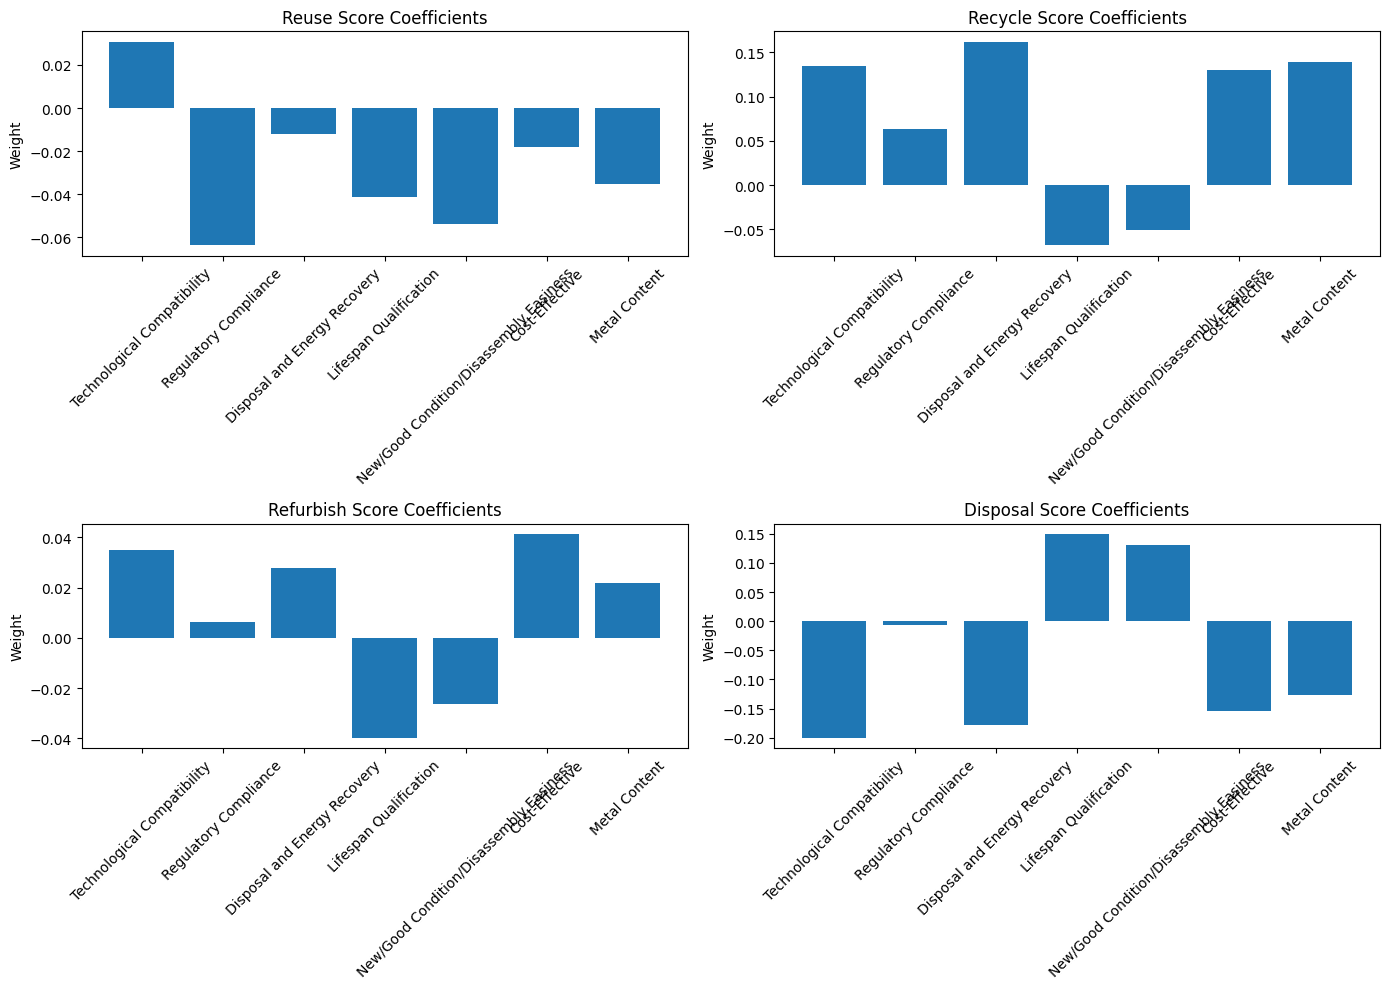

In [4]:
import matplotlib.pyplot as plt

# Plot the weights for each pathway
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, pathway in enumerate(weights_df.columns):
    axes[i].bar(weights_df.index, weights_df[pathway])
    axes[i].set_title(f"{pathway} Score Coefficients")
    axes[i].set_ylabel("Weight")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# **Survey-based Weights Model**

In [1]:
import pandas as pd

# Load the Excel file
file_path = 'test-survey.xlsx'  # Replace with your actual file name
xls = pd.ExcelFile(file_path)

# Lists to store data from each sheet
reuse_list = []
recycle_list = []
refurbish_list = []
disposal_list = []

# Loop through all sheet names
for sheet_name in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    
    reuse_list.append(df['Reuse'].values)
    recycle_list.append(df['Recycle'].values)
    refurbish_list.append(df['Refurbish'].values)
    disposal_list.append(df['Disposal'].values)

# Convert to DataFrame for easier calculations
reuse_df = pd.DataFrame(reuse_list)
recycle_df = pd.DataFrame(recycle_list)
refurbish_df = pd.DataFrame(refurbish_list)
disposal_df = pd.DataFrame(disposal_list)

# Calculate mean and standard deviation
results = {
    'Reuse_avg': reuse_df.mean(),
    'Reuse_std': reuse_df.std(),
    'Recycle_avg': recycle_df.mean(),
    'Recycle_std': recycle_df.std(),
    'Refurbish_avg': refurbish_df.mean(),
    'Refurbish_std': refurbish_df.std(),
    'Disposal_avg': disposal_df.mean(),
    'Disposal_std': disposal_df.std()
}

# Combine results into a single DataFrame
summary = pd.DataFrame(results)

# # If you want to save the results
# summary.to_excel('summary_results.xlsx', index=True)

summary

,Reuse_avg,Reuse_std,Recycle_avg,Recycle_std,Refurbish_avg,Refurbish_std,Disposal_avg,Disposal_std
0,1.40,1.231174,1.55,1.099043,1.80,1.321881,1.85,1.136708
1,1.60,1.095445,1.60,1.273206,1.60,1.142481,0.95,1.145931
2,1.45,1.234376,1.50,1.277333,1.70,1.174286,1.95,1.145931
3,1.55,1.190975,1.30,1.128576,1.60,1.095445,1.85,0.812728
4,1.80,1.151658,1.65,1.039990,1.65,1.182103,1.75,1.118034
5,1.60,0.994723,1.40,1.187656,2.05,1.099043,1.25,1.118034
6,1.65,1.182103,1.80,0.951453,1.45,1.145931,1.05,1.276302


   Reuse Mean  Reuse Std  Recycle Mean  Recycle Std  Refurbish Mean  \
0   11.434303   2.826979     11.125648     2.774234       12.131984   

   Refurbish Std  Disposal Mean  Disposal Std  
0       2.888293      11.082331      2.680878  


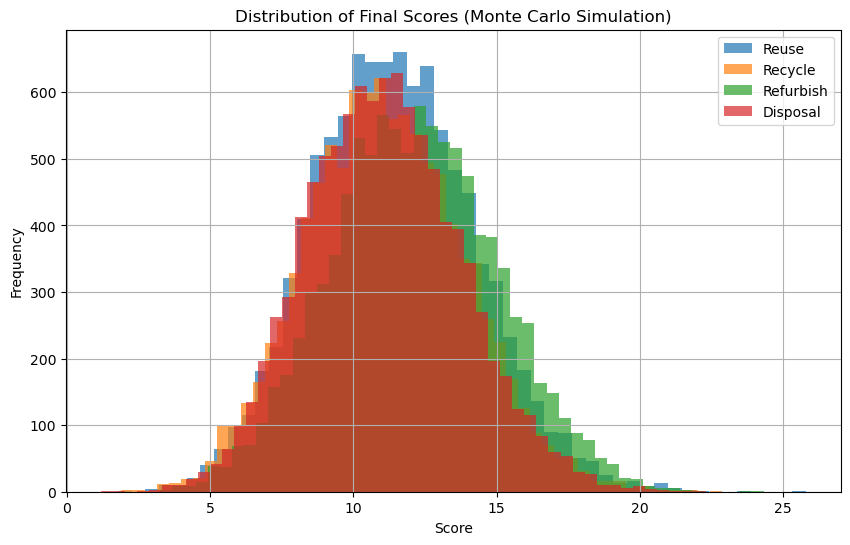

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

criteria = ['Technology', 'Regulatory', 'Disposal', 'Lifespan', 'Disassembly', 'Cost-Effectiveness', 'Metal Content']

# Step 2: Assume Compatibility = 1 for all criteria (can be customized)
criteria_scores = np.ones(len(criteria))  # [1,1,1,1,1,1,1]

# Step 3: Setup
n_simulations = 10000
reuse_scores = []
recycle_scores = []
refurbish_scores = []
disposal_scores = []

# Step 4: Monte Carlo sampling
for _ in range(n_simulations):
    reuse_sum = 0
    recycle_sum = 0
    refurbish_sum = 0
    disposal_sum = 0
    
    for idx in range(len(criteria)):
        # Sample weights
        reuse_weight = np.random.normal(summary.loc[idx, 'Reuse_avg'], summary.loc[idx, 'Reuse_std'])
        recycle_weight = np.random.normal(summary.loc[idx, 'Recycle_avg'], summary.loc[idx, 'Recycle_std'])
        refurbish_weight = np.random.normal(summary.loc[idx, 'Refurbish_avg'], summary.loc[idx, 'Refurbish_std'])
        disposal_weight = np.random.normal(summary.loc[idx, 'Disposal_avg'], summary.loc[idx, 'Disposal_std'])
        
        # Optional: Clip negative values to 0
        reuse_weight = max(reuse_weight, 0)
        recycle_weight = max(recycle_weight, 0)
        refurbish_weight = max(refurbish_weight, 0)
        disposal_weight = max(disposal_weight, 0)
        
        # Sum scores
        reuse_sum += reuse_weight * criteria_scores [idx]
        recycle_sum += recycle_weight * criteria_scores [idx]
        refurbish_sum += refurbish_weight * criteria_scores [idx]
        disposal_sum += disposal_weight * criteria_scores [idx]
    
    reuse_scores.append(reuse_sum)
    recycle_scores.append(recycle_sum)
    refurbish_scores.append(refurbish_sum)
    disposal_scores.append(disposal_sum)

# Step 5: Calculate results
reuse_scores = np.array(reuse_scores)
recycle_scores = np.array(recycle_scores)
refurbish_scores = np.array(refurbish_scores)
disposal_scores = np.array(disposal_scores)

results = {
    'Reuse Mean': np.mean(reuse_scores),
    'Reuse Std': np.std(reuse_scores),
    'Recycle Mean': np.mean(recycle_scores),
    'Recycle Std': np.std(recycle_scores),
    'Refurbish Mean': np.mean(refurbish_scores),
    'Refurbish Std': np.std(refurbish_scores),
    'Disposal Mean': np.mean(disposal_scores),
    'Disposal Std': np.std(disposal_scores)
}

results_df = pd.DataFrame([results])
print(results_df)

# Step 6: Optional plotting
plt.figure(figsize=(10, 6))
plt.hist(reuse_scores, bins=50, alpha=0.7, label='Reuse')
plt.hist(recycle_scores, bins=50, alpha=0.7, label='Recycle')
plt.hist(refurbish_scores, bins=50, alpha=0.7, label='Refurbish')
plt.hist(disposal_scores, bins=50, alpha=0.7, label='Disposal')
plt.legend()
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Final Scores (Monte Carlo Simulation)')
plt.grid(True)
plt.show()


In [3]:
def confidence_interval(arr, confidence=0.95):
    lower = np.percentile(arr, (1 - confidence) / 2 * 100)
    upper = np.percentile(arr, (1 + confidence) / 2 * 100)
    return lower, upper

print('Reuse 95% CI:', confidence_interval(reuse_scores))
print('Recycle 95% CI:', confidence_interval(recycle_scores))
print('Refurbish 95% CI:', confidence_interval(refurbish_scores))
print('Disposal 95% CI:', confidence_interval(disposal_scores))


Reuse 95% CI: (6.114333162128513, 17.24300379768515)
Recycle 95% CI: (5.836275113246945, 16.693601318958287)
Refurbish 95% CI: (6.619012809641836, 17.903649927826777)
Disposal 95% CI: (6.126785708007216, 16.554061513493338)


           Component   Strategy  Mean Score    Std Dev  95% CI Lower  \
0   Electrical Cable      Reuse   43.282344  12.153779     20.627499   
1             Boiler      Reuse   39.712416  10.492015     20.063945   
2         Water Pipe      Reuse   23.823209   7.983274      9.395182   
3           Air Duct      Reuse   31.153457   9.227491     14.124786   
4           Radiator      Reuse   34.796042   9.673373     16.677062   
5          Heat Pump      Reuse   57.043052  13.927789     30.862399   
6             Toilet      Reuse   38.714680  10.762537     18.745695   
7               Sink      Reuse   38.714680  10.762537     18.745695   
8             Shower      Reuse   38.714680  10.762537     18.745695   
9            Bathtub      Reuse   38.714680  10.762537     18.745695   
10  Electrical Cable    Recycle   43.133105  12.011110     20.525660   
11            Boiler    Recycle   38.237428  10.575106     18.256743   
12        Water Pipe    Recycle   22.916385   7.626619      9.10

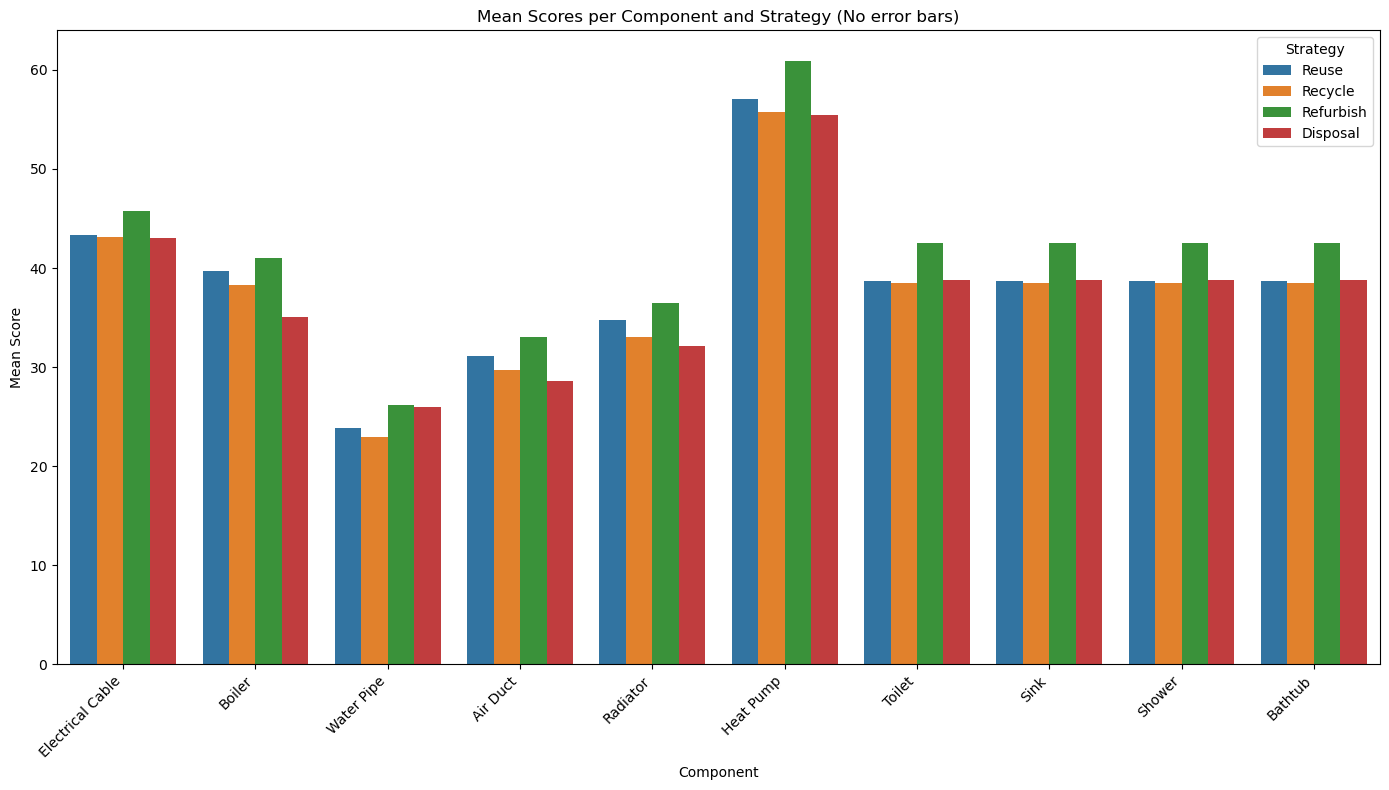

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


criteria = [
    'Technological Compatibility',
    'Regulatory Compliance',
    'Disposal and Energy Recovery',
    'Lifespan Qualification',
    'New/Good Condition/Disassembly Easiness',
    'Cost-Effective',
    'Metal Content'
]

# Step 2: Your components and their scores
# (you can load from Excel or copy manually)
components = pd.DataFrame({
    'Component': ['Electrical Cable', 'Boiler', 'Water Pipe', 'Air Duct', 'Radiator', 'Heat Pump', 'Toilet', 'Sink', 'Shower', 'Bathtub'],
    'Material': ['Copper', 'Steel', 'PEX', 'Aluminum', 'Steel', 'Steel', 'Ceramic', 'Ceramic', 'Ceramic', 'Ceramic'],
    'Technological Compatibility': [5, 1, 5, 1, 1, 5, 5, 5, 5, 5],
    'Regulatory Compliance': [5, 5, 1, 1, 1, 5, 5, 5, 5, 5],
    'Disposal and Energy Recovery': [5, 1, 1, 1, 1, 5, 5, 5, 5, 5],
    'Lifespan Qualification': [5, 5, 5, 5, 5, 5, 1, 1, 1, 1],
    'New/Good Condition/Disassembly Easiness': [1, 3, 1, 1, 3, 5, 4, 4, 4, 4],
    'Cost-Effective': [1, 4, 1, 5, 5, 5, 3, 3, 3, 3],
    'Metal Content': [5, 5, 1, 5, 5, 5, 1, 1, 1, 1]
})

components.set_index('Component', inplace=True)

# Step 3: Monte Carlo sampling setup
n_simulations = 10000

# Storage for results
results = {}

for strategy in ['Reuse', 'Recycle', 'Refurbish', 'Disposal']:
    results[strategy] = {comp: [] for comp in components.index}

# Step 4: Perform Monte Carlo sampling
for _ in range(n_simulations):
    sampled_weights = {}
    
    for idx, crit in enumerate(criteria):
        sampled_weights[(crit, 'Reuse')] = max(0, np.random.normal(summary.loc[idx, 'Reuse_avg'], summary.loc[idx, 'Reuse_std']))
        sampled_weights[(crit, 'Recycle')] = max(0, np.random.normal(summary.loc[idx, 'Recycle_avg'], summary.loc[idx, 'Recycle_std']))
        sampled_weights[(crit, 'Refurbish')] = max(0, np.random.normal(summary.loc[idx, 'Refurbish_avg'], summary.loc[idx, 'Refurbish_std']))
        sampled_weights[(crit, 'Disposal')] = max(0, np.random.normal(summary.loc[idx, 'Disposal_avg'], summary.loc[idx, 'Disposal_std']))
    
    for comp in components.index:
        for strategy in ['Reuse', 'Recycle', 'Refurbish', 'Disposal']:
            score = 0
            for crit in criteria:
                crit_score = components.loc[comp, crit]
                weight = sampled_weights[(crit, strategy)]
                score += weight * crit_score
            results[strategy][comp].append(score)

# Step 5: Aggregate Results
final_results = []

def confidence_interval(arr, confidence=0.95):
    lower = np.percentile(arr, (1 - confidence) / 2 * 100)
    upper = np.percentile(arr, (1 + confidence) / 2 * 100)
    return lower, upper

for strategy in results:
    for comp in results[strategy]:
        scores = np.array(results[strategy][comp])
        mean = scores.mean()
        std = scores.std()
        ci_lower, ci_upper = confidence_interval(scores)
        final_results.append({
            'Component': comp,
            'Strategy': strategy,
            'Mean Score': mean,
            'Std Dev': std,
            '95% CI Lower': ci_lower,
            '95% CI Upper': ci_upper
        })

final_df = pd.DataFrame(final_results)
print(final_df)

# Step 6: Optional Plotting
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.barplot(data=final_df, x='Component', y='Mean Score', hue='Strategy', errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.title('Mean Scores per Component and Strategy (No error bars)')
plt.tight_layout()
plt.show()


In [ ]:
# Step 1: Define all components

components = {
    'Radiator': {
        'Lp': 30,
        'obsolescence': {
            'Technological Compatibility': 0.05,
            'Regulatory Compliance': 0.03,
            'Disposal and Energy Recovery': 0.02,
            'Lifespan Qualification': 0.04,
            'Disassembly Easiness': 0.03,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 20  # example
    },
    'Electrical Cable': {
        'Lp': 60,
        'obsolescence': {
            'Technological Compatibility': 0.02,
            'Regulatory Compliance': 0.01,
            'Disposal and Energy Recovery': 0.01,
            'Lifespan Qualification': 0.03,
            'Disassembly Easiness': 0.02,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 30  # example
    },
    'Water Pipe': {
        'Lp': 50,
        'obsolescence': {
            'Technological Compatibility': 0.04,
            'Regulatory Compliance': 0.02,
            'Disposal and Energy Recovery': 0.02,
            'Lifespan Qualification': 0.03,
            'Disassembly Easiness': 0.03,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 25  # example
    }
    # ➔ You can add more components easily here
}

# Step 2: Functions (already validated)

def calculate_custom_useful_life(Lp, criteria_obsolescence):
    total_obsolescence = sum(criteria_obsolescence.values())
    Lu = Lp / ((1 + total_obsolescence / Lp) ** Lp)
    return Lu

def calculate_component_arp(elu, elb):
    if elb < elu:
        arp = ((100 - (elu * elu / 100)) / elu) * elb
    else:
        arp = ((100 - (elu * elu / 100)) / (100 - elu)) * (100 - elb)
    return max(arp, 0)

# Step 3: Calculate for all components

results = []

for comp_name, comp_info in components.items():
    Lp = comp_info['Lp']
    age = comp_info['age']
    obsolescence = comp_info['obsolescence']
    
    # 1. Useful Life
    Lu = calculate_custom_useful_life(Lp, obsolescence)
    
    # 2. Effective Useful Life (percentage)
    ELu = Lu * 100 / Lp
    
    # 3. Effective Component Age (percentage)
    ELb = age * 100 / Lp
    
    # 4. Effective Physical Life (always 100%)
    ELp = 100
    
    # 5. Max Reuse Potential at ELu
    y = 100 - (ELu ** 2) / 100
    
    # 6. ARP
    arp = calculate_component_arp(ELu, ELb)
    
    results.append({
        'Component': comp_name,
        'Physical Life (Lp)': Lp,
        'Useful Life (Lu)': Lu,
        'Effective Useful Life (ELu)': ELu,
        'Effective Component Age (ELb)': ELb,
        'Max Potential at ELu': y,
        'ARP (%)': arp
    })

# Step 4: Present results
import pandas as pd

results_df = pd.DataFrame(results)
pd.set_option('display.precision', 2)
results_df


,Component,Physical Life (Lp),Useful Life (Lu),Effective Useful Life (ELu),Effective Component Age (ELb),Max Potential at ELu,ARP (%)
0,Radiator,30,24.58,81.93,66.67,32.88,26.75
1,Electrical Cable,60,53.22,88.70,50.00,21.32,12.02
2,Water Pipe,50,42.20,84.39,50.00,28.78,17.05


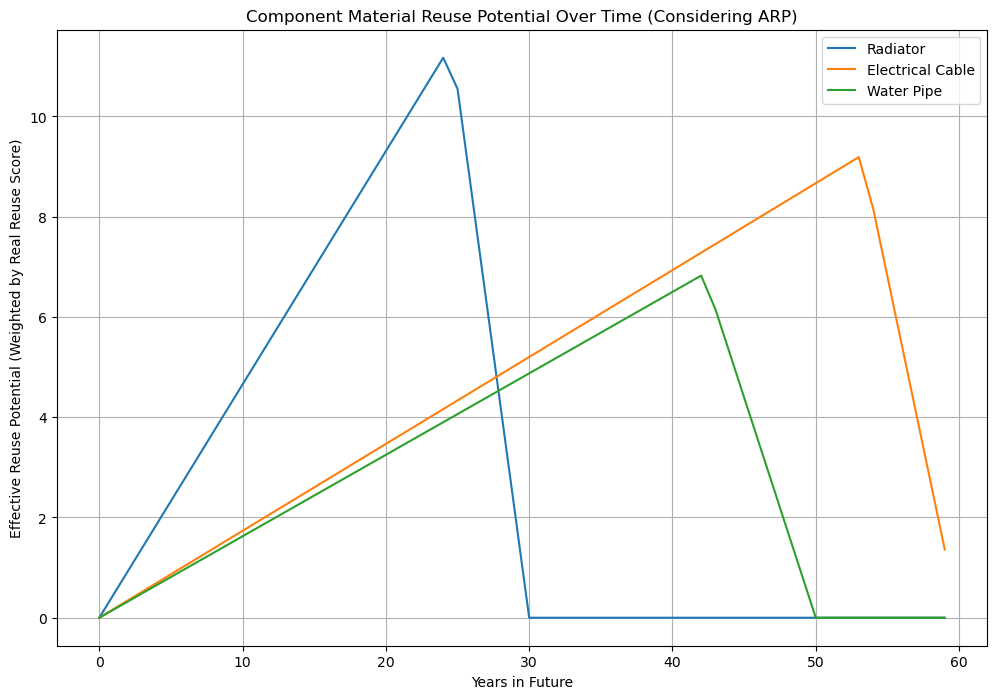

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Extract Reuse mean scores from final_df
# Build a mapping: {component: reuse_mean_score}
reuse_scores = final_df[final_df['Strategy'] == 'Reuse'].set_index('Component')['Mean Score'].to_dict()

# Step 2: Simulation setup
years = np.arange(0, 60)  # Simulate 50 years
simulation_results = {}

for name, comp in components.items():
    Lp = comp['Lp']
    obsolescence = comp['obsolescence']
    
    # Calculate Useful Life
    Lu = calculate_custom_useful_life(Lp, obsolescence)
    
    reuse_potential = []
    
    for year in years:
        current_age = year
        ELu = Lu * 100 / Lp  # Effective Useful Life (%)
        ELb = current_age * 100 / Lp  # Effective Component Age (%)
        
        arp = calculate_component_arp(ELu, ELb)
        
        # Use reuse score from Monte Carlo simulation
        reuse_score = reuse_scores.get(name, 1.0)  # fallback 1.0 if missing
        
        effective_reuse = reuse_score * (arp / 100)
        reuse_potential.append(effective_reuse)
    
    simulation_results[name] = reuse_potential

# Step 3: Plotting
plt.figure(figsize=(12, 8))
for name, reuse_potential in simulation_results.items():
    plt.plot(years, reuse_potential, label=f"{name}")

plt.xlabel('Years in Future')
plt.ylabel('Effective Reuse Potential (Weighted by Real Reuse Score)')
plt.title('Component Material Reuse Potential Over Time (Considering ARP)')
plt.legend()
plt.grid(True)
plt.show()


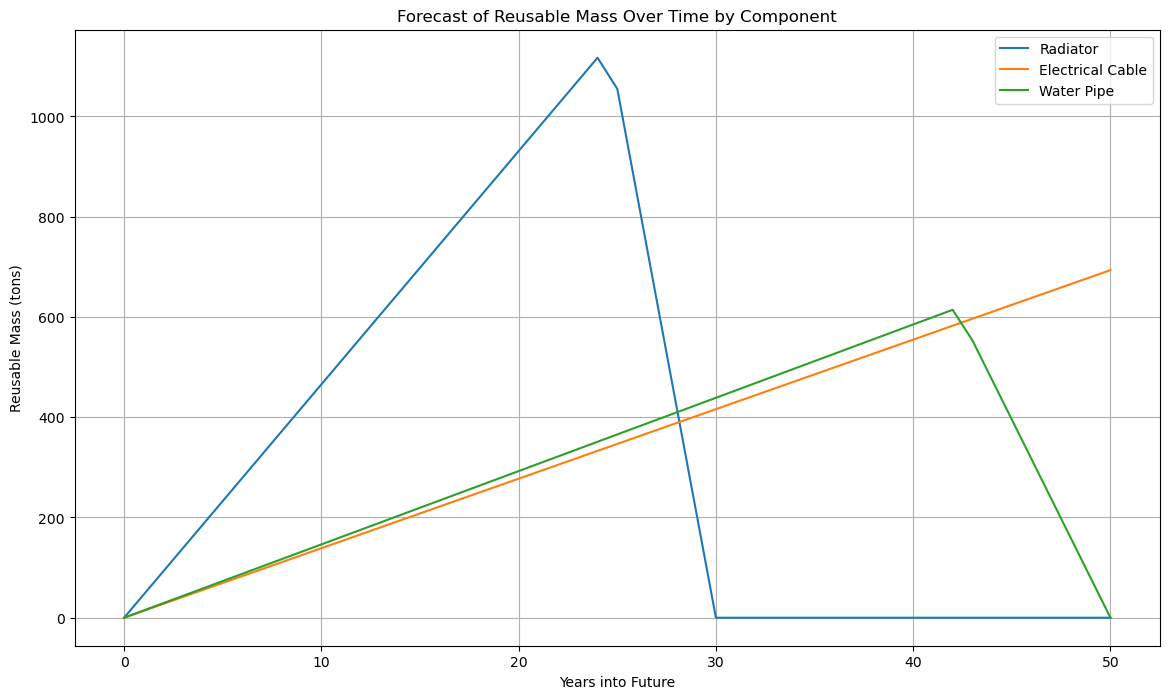

      Radiator  Electrical Cable  Water Pipe
Year                                        
0         0.00              0.00        0.00
1        46.55             13.87       14.63
2        93.10             27.74       29.25
3       139.64             41.61       43.88
4       186.19             55.48       58.50
5       232.74             69.35       73.13
6       279.29             83.22       87.75
7       325.83             97.09      102.38
8       372.38            110.96      117.00
9       418.93            124.83      131.63


In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Define Installed Mass (example values)
installed_mass = {
    'Radiator': 100,         # tons
    'Electrical Cable': 80,  # tons
    'Water Pipe': 90         # tons
}

# Step 2: Years to simulate
years = np.arange(0, 51)  # 0 to 50 years

# Step 3: Reuse Scores extracted from your final_df
reuse_scores = final_df[final_df['Strategy'] == 'Reuse'].set_index('Component')['Mean Score'].to_dict()

# Step 4: Simulate Mass Flow Over Time
mass_forecast = {}

for name, comp in components.items():
    Lp = comp['Lp']
    obsolescence = comp['obsolescence']
    
    # Calculate Useful Life
    Lu = calculate_custom_useful_life(Lp, obsolescence)
    
    reuse_mass = []
    
    for year in years:
        current_age = year
        ELu = Lu * 100 / Lp
        ELb = current_age * 100 / Lp
        
        arp = calculate_component_arp(ELu, ELb)
        
        # Reuse score from your real Monte Carlo simulation
        reuse_score = reuse_scores.get(name, 1.0)
        
        effective_reuse = reuse_score * (arp / 100)  # still between 0-1
        
        mass_now = installed_mass.get(name, 0) * effective_reuse
        reuse_mass.append(mass_now)
    
    mass_forecast[name] = reuse_mass

# Step 5: Plot the Forecast
plt.figure(figsize=(14, 8))
for name, mass_over_time in mass_forecast.items():
    plt.plot(years, mass_over_time, label=name)

plt.xlabel('Years into Future')
plt.ylabel('Reusable Mass (tons)')
plt.title('Forecast of Reusable Mass Over Time by Component')
plt.legend()
plt.grid(True)
plt.show()

# Step 6: Create a Table to Review
mass_forecast_df = pd.DataFrame(mass_forecast, index=years)
mass_forecast_df.index.name = 'Year'
print(mass_forecast_df.head(10))  # Show first 10 years


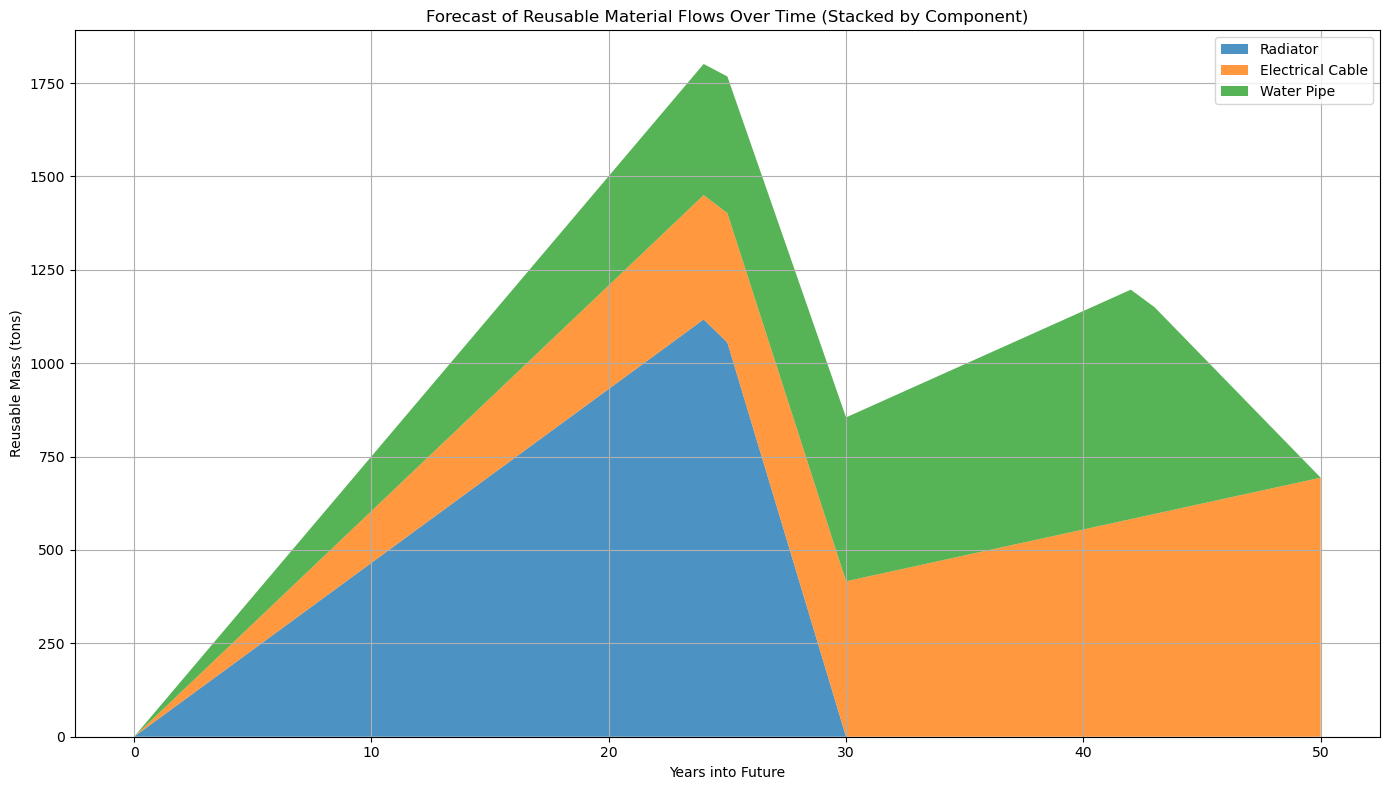

In [46]:
import matplotlib.pyplot as plt

# Assuming mass_forecast_df has already been created
# mass_forecast_df: rows = years, columns = component names

# Step 1: Stacked Area Plot
plt.figure(figsize=(14, 8))

# Stacked area chart
plt.stackplot(
    mass_forecast_df.index,
    [mass_forecast_df[comp] for comp in mass_forecast_df.columns],
    labels=mass_forecast_df.columns,
    alpha=0.8
)

plt.xlabel('Years into Future')
plt.ylabel('Reusable Mass (tons)')
plt.title('Forecast of Reusable Material Flows Over Time (Stacked by Component)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# # Step 2: Optional - Line plot for Total Reusable Mass
# mass_forecast_df['Total'] = mass_forecast_df.sum(axis=1)

# plt.figure(figsize=(12, 6))
# plt.plot(mass_forecast_df.index, mass_forecast_df['Total'], color='black', linewidth=2)
# plt.xlabel('Years into Future')
# plt.ylabel('Total Reusable Mass (tons)')
# plt.title('Total Forecasted Reusable Material Mass Over Time')
# plt.grid(True)
# plt.tight_layout()
# plt.show()


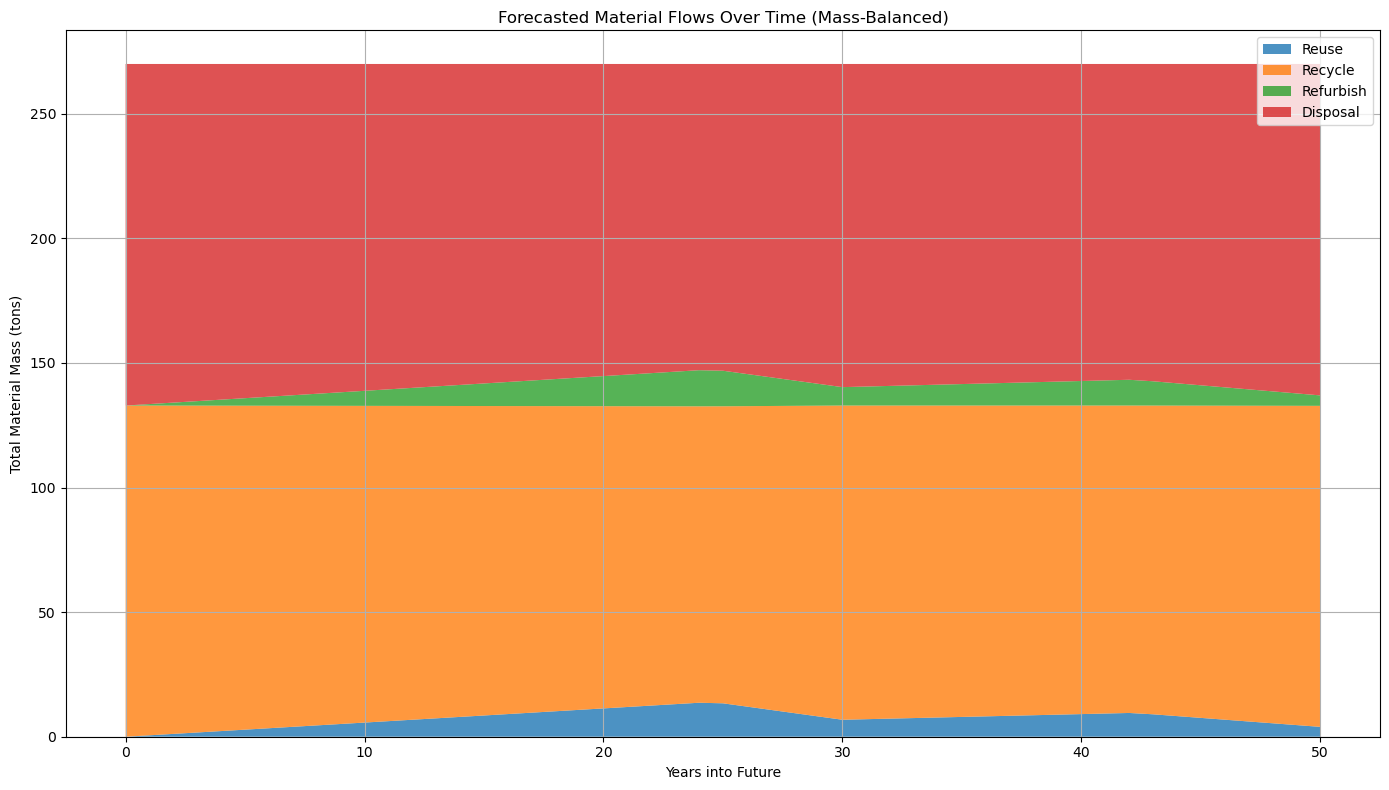

      Total
Year       
0     270.0
1     270.0
2     270.0
3     270.0
4     270.0
5     270.0
6     270.0
7     270.0
8     270.0
9     270.0


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Installed Mass per component (example)
installed_mass = {
    'Radiator': 100,
    'Electrical Cable': 80,
    'Water Pipe': 90
}

# Step 2: Extract scores for all paths
reuse_scores = final_df[final_df['Strategy'] == 'Reuse'].set_index('Component')['Mean Score'].to_dict()
recycle_scores = final_df[final_df['Strategy'] == 'Recycle'].set_index('Component')['Mean Score'].to_dict()
refurbish_scores = final_df[final_df['Strategy'] == 'Refurbish'].set_index('Component')['Mean Score'].to_dict()
disposal_scores = final_df[final_df['Strategy'] == 'Disposal'].set_index('Component')['Mean Score'].to_dict()

# Step 3: Setup
years = np.arange(0, 51)
mass_forecast_all_paths = {
    'Reuse': [],
    'Recycle': [],
    'Refurbish': [],
    'Disposal': []
}

# Step 4: Simulate each year
for year in years:
    reuse_total = 0
    recycle_total = 0
    refurbish_total = 0
    disposal_total = 0
    
    for name, comp in components.items():
        # Physical properties
        Lp = comp['Lp']
        obsolescence = comp['obsolescence']
        mass_now = installed_mass.get(name, 0)
        
        # Scores
        reuse_score = reuse_scores.get(name, 0)
        recycle_score = recycle_scores.get(name, 0)
        refurbish_score = refurbish_scores.get(name, 0)
        disposal_score = disposal_scores.get(name, 0)
        
        # Sum scores
        total_score = reuse_score + recycle_score + refurbish_score + disposal_score
        
        if total_score == 0:
            continue  # Skip if no scores
        
        # Path shares (%)
        reuse_share = reuse_score / total_score
        recycle_share = recycle_score / total_score
        refurbish_share = refurbish_score / total_score
        disposal_share = disposal_score / total_score
        
        # Calculate Useful Life and ARP
        Lu = calculate_custom_useful_life(Lp, obsolescence)
        ELu = Lu * 100 / Lp
        ELb = year * 100 / Lp
        
        arp = calculate_component_arp(ELu, ELb)
        
        # Step 1: Apply ARP to Reuse and Refurbish paths
        effective_reuse = mass_now * reuse_share * (arp / 100)
        effective_refurbish = mass_now * refurbish_share * (arp / 100)
        
        # Calculate lost mass
        lost_reuse = mass_now * reuse_share * (1 - arp / 100)
        lost_refurbish = mass_now * refurbish_share * (1 - arp / 100)
        lost_mass = lost_reuse + lost_refurbish
        
        # Step 2: Reallocate lost mass proportionally to Recycle and Disposal
        total_rd_share = recycle_share + disposal_share
        
        if total_rd_share > 0:
            recycle_extra = (recycle_share / total_rd_share) * lost_mass
            disposal_extra = (disposal_share / total_rd_share) * lost_mass
        else:
            recycle_extra = 0
            disposal_extra = 0
        
        effective_recycle = mass_now * recycle_share + recycle_extra
        effective_disposal = mass_now * disposal_share + disposal_extra
        
        # Step 3: Add to totals
        reuse_total += effective_reuse
        recycle_total += effective_recycle
        refurbish_total += effective_refurbish
        disposal_total += effective_disposal
        
    # Store for this year
    mass_forecast_all_paths['Reuse'].append(reuse_total)
    mass_forecast_all_paths['Recycle'].append(recycle_total)
    mass_forecast_all_paths['Refurbish'].append(refurbish_total)
    mass_forecast_all_paths['Disposal'].append(disposal_total)

# Step 5: Create DataFrame
mass_forecast_df = pd.DataFrame(mass_forecast_all_paths, index=years)
mass_forecast_df.index.name = 'Year'

# Step 6: Plot Stacked Area Chart
plt.figure(figsize=(14, 8))

plt.stackplot(
    mass_forecast_df.index,
    mass_forecast_df['Reuse'],
    mass_forecast_df['Recycle'],
    mass_forecast_df['Refurbish'],
    mass_forecast_df['Disposal'],
    labels=['Reuse', 'Recycle', 'Refurbish', 'Disposal'],
    alpha=0.8
)

plt.xlabel('Years into Future')
plt.ylabel('Total Material Mass (tons)')
plt.title('Forecasted Material Flows Over Time (Mass-Balanced)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Optional: Check Total Mass
mass_forecast_df['Total'] = mass_forecast_df[['Reuse', 'Recycle', 'Refurbish', 'Disposal']].sum(axis=1)
print(mass_forecast_df[['Total']].head(10))  # See if total is constant



In [47]:
import pandas as pd

# --- Step 0: Sample component-material data ---
data = {
    "year_of_construction": [1530.0, 1530.0, 1530.0, 1530.0, 1530.0, 2021.0, 2021.0, 2021.0, 2021.0, 2021.0],
    "building_class": ["housing"]*10,
    "building_system": ["electrical system", "electrical system", "heating system", "heating system", "heating system", "plumbing system", "plumbing system", "plumbing system", "plumbing system", "plumbing system"],
    "sub_system": ["electrical wiring and cables", "electrical wiring and cables", "heating", "heating", "heating", "drainage and waste pipes", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures"],
    "component": ["electrical cable", "electrical cable", "boiler", "boiler", "boiler", "water pipe", "water pipe", "water pipe", "water pipe", "water pipe"],
    "material": ["copper", "pvc", "aluminum", "brass", "copper", "zinc coating", "copper", "pex", "steel", "zinc coating"],
    "material_weight": [0.002017, 0.078648, 1.030000, 1.030000, 5.150000, 0.000000, 0.000000, 16.050662, 0.000000, 0.000000]
}

df = pd.DataFrame(data)

# --- Step 1: Components information (with obsolescence) ---
components = {
    'Radiator': {
        'Lp': 30,
        'obsolescence': {
            'Technological Compatibility': 0.05,
            'Regulatory Compliance': 0.03,
            'Disposal and Energy Recovery': 0.02,
            'Lifespan Qualification': 0.04,
            'Disassembly Easiness': 0.03,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 20
    },
    'Electrical Cable': {
        'Lp': 60,
        'obsolescence': {
            'Technological Compatibility': 0.02,
            'Regulatory Compliance': 0.01,
            'Disposal and Energy Recovery': 0.01,
            'Lifespan Qualification': 0.03,
            'Disassembly Easiness': 0.02,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 30
    },
    'Water Pipe': {
        'Lp': 50,
        'obsolescence': {
            'Technological Compatibility': 0.04,
            'Regulatory Compliance': 0.02,
            'Disposal and Energy Recovery': 0.02,
            'Lifespan Qualification': 0.03,
            'Disassembly Easiness': 0.03,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 25
    },
    'Boiler': {
        'Lp': 20,
        'obsolescence': {
            'Technological Compatibility': 0.03,
            'Regulatory Compliance': 0.02,
            'Disposal and Energy Recovery': 0.01,
            'Lifespan Qualification': 0.03,
            'Disassembly Easiness': 0.02,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 10
    },
    'Heat Pump': {
        'Lp': 15,
        'obsolescence': {
            'Technological Compatibility': 0.02,
            'Regulatory Compliance': 0.01,
            'Disposal and Energy Recovery': 0.01,
            'Lifespan Qualification': 0.02,
            'Disassembly Easiness': 0.02,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 5
    }
}

# --- Step 2: (Simulated) final_df from Monte Carlo results ---
# (Replace this with your real final_df when available)
final_df

# --- Step 3: Calculate distributions from scores ---
component_distributions = {}

for component in final_df['Component'].unique():
    subset = final_df[final_df['Component'] == component]
    reuse_score = subset[subset['Strategy'] == 'Reuse']['Mean Score'].values[0]
    recycle_score = subset[subset['Strategy'] == 'Recycle']['Mean Score'].values[0]
    refurbish_score = subset[subset['Strategy'] == 'Refurbish']['Mean Score'].values[0]
    disposal_score = subset[subset['Strategy'] == 'Disposal']['Mean Score'].values[0]
    
    total = reuse_score + recycle_score + refurbish_score + disposal_score
    if total == 0:
        reuse_share = recycle_share = refurbish_share = disposal_share = 0
    else:
        reuse_share = reuse_score / total
        recycle_share = recycle_score / total
        refurbish_share = refurbish_score / total
        disposal_share = disposal_score / total
    
    component_distributions[component] = {
        'reuse': reuse_share,
        'recycle': recycle_share,
        'refurbish': refurbish_share,
        'disposal': disposal_share
    }

print("\nCalculated Component Distributions:")
print(pd.DataFrame(component_distributions).T)

# --- Step 4: Define functions to calculate ARP ---

current_year = 2024

def calculate_custom_useful_life(Lp, criteria_obsolescence):
    total_obsolescence = sum(criteria_obsolescence.values())
    Lu = Lp / ((1 + total_obsolescence / Lp) ** Lp)
    return Lu

def calculate_component_arp_full(Lp, obsolescence, age):
    Lu = calculate_custom_useful_life(Lp, obsolescence)
    ELu = Lu * 100 / Lp
    ELb = age * 100 / Lp

    if ELb < ELu:
        arp = ((100 - (ELu * ELu / 100)) / ELu) * ELb
    else:
        if abs(100 - ELu) < 1e-6:
            arp = 0
        else:
            arp = ((100 - (ELu * ELu / 100)) / (100 - ELu)) * (100 - ELb)
    return max(arp, 0) / 100  # return decimal

# --- Step 5: Apply ARP + Distribution to each row ---
def classify_component(row):
    component = row['component'].lower()  # match lowercase because your final_df uses lowercase
    material = row['material']
    mass = row['material_weight']
    age = current_year - row['year_of_construction']
    
    # Get matching component info
    comp_info = None
    for key in components.keys():
        if key.lower() == component:
            comp_info = components[key]
            break

    if comp_info is None:
        # If component info not found, assume no reuse
        row['reuse_mass'] = 0
        row['recycle_mass'] = 0
        row['refurbish_mass'] = 0
        row['disposal_mass'] = mass
        return row

    Lp = comp_info['Lp']
    obsolescence = comp_info['obsolescence']

    dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 1})
    arp_factor = calculate_component_arp_full(Lp, obsolescence, age)

    reuse_share = dist['reuse'] * arp_factor
    refurbish_share = dist['refurbish'] * arp_factor

    lost_reuse_refurbish = dist['reuse'] * (1 - arp_factor) + dist['refurbish'] * (1 - arp_factor)

    recycle_share = dist['recycle']
    disposal_share = dist['disposal']
    total_rd = recycle_share + disposal_share

    if total_rd > 0:
        recycle_share += (dist['recycle'] / total_rd) * lost_reuse_refurbish
        disposal_share += (dist['disposal'] / total_rd) * lost_reuse_refurbish

    # Normalize
    total = reuse_share + recycle_share + refurbish_share + disposal_share
    reuse_share /= total
    recycle_share /= total
    refurbish_share /= total
    disposal_share /= total

    # Mass flow
    row['reuse_mass'] = mass * reuse_share
    row['recycle_mass'] = mass * recycle_share
    row['refurbish_mass'] = mass * refurbish_share
    row['disposal_mass'] = mass * disposal_share

    return row

# Apply classification
df = df.apply(classify_component, axis=1)

# # --- Step 6: Final table ---
# pd.set_option('display.precision', 6)
# print("\nFinal Material Flows per Row:")
# print(df[['component', 'material', 'material_weight', 'reuse_mass', 'recycle_mass', 'refurbish_mass', 'disposal_mass']])



Calculated Component Distributions:
                  reuse  recycle  refurbish  disposal
Electrical Cable   0.25     0.25       0.26      0.25
Boiler             0.26     0.25       0.27      0.23
Water Pipe         0.24     0.23       0.26      0.26
Air Duct           0.25     0.24       0.27      0.23
Radiator           0.26     0.24       0.27      0.24
Heat Pump          0.25     0.24       0.27      0.24
Toilet             0.24     0.24       0.27      0.24
Sink               0.24     0.24       0.27      0.24
Shower             0.24     0.24       0.27      0.24
Bathtub            0.24     0.24       0.27      0.24


In [ ]:
import pandas as pd
import plotly.graph_objects as go


# --- Step 0: Sample component-material data ---
data = {
    "year_of_construction": [1530.0, 1530.0, 1530.0, 1530.0, 1530.0, 2021.0, 2021.0, 2021.0, 2021.0, 2021.0],
    "building_class": ["housing"]*10,
    "building_system": ["electrical system", "electrical system", "heating system", "heating system", "heating system", "plumbing system", "plumbing system", "plumbing system", "plumbing system", "plumbing system"],
    "sub_system": ["electrical wiring and cables", "electrical wiring and cables", "heating", "heating", "heating", "drainage and waste pipes", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures"],
    "component": ["electrical cable", "electrical cable", "boiler", "boiler", "boiler", "water pipe", "water pipe", "water pipe", "water pipe", "water pipe"],
    "material": ["copper", "pvc", "aluminum", "brass", "copper", "zinc coating", "copper", "pex", "steel", "zinc coating"],
    "material_weight": [0.002017, 0.078648, 1.030000, 1.030000, 5.150000, 0.000000, 0.000000, 16.050662, 0.000000, 0.000000]
}

df = pd.DataFrame(data)

# --- Step 1: Components information (with obsolescence) ---
components = {
    'Radiator': {
        'Lp': 30,
        'obsolescence': {
            'Technological Compatibility': 0.05,
            'Regulatory Compliance': 0.03,
            'Disposal and Energy Recovery': 0.02,
            'Lifespan Qualification': 0.04,
            'Disassembly Easiness': 0.03,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 20
    },
    'Electrical Cable': {
        'Lp': 60,
        'obsolescence': {
            'Technological Compatibility': 0.02,
            'Regulatory Compliance': 0.01,
            'Disposal and Energy Recovery': 0.01,
            'Lifespan Qualification': 0.03,
            'Disassembly Easiness': 0.02,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 30
    },
    'Water Pipe': {
        'Lp': 50,
        'obsolescence': {
            'Technological Compatibility': 0.04,
            'Regulatory Compliance': 0.02,
            'Disposal and Energy Recovery': 0.02,
            'Lifespan Qualification': 0.03,
            'Disassembly Easiness': 0.03,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 25
    },
    'Boiler': {
        'Lp': 20,
        'obsolescence': {
            'Technological Compatibility': 0.03,
            'Regulatory Compliance': 0.02,
            'Disposal and Energy Recovery': 0.01,
            'Lifespan Qualification': 0.03,
            'Disassembly Easiness': 0.02,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 10
    },
    'Heat Pump': {
        'Lp': 15,
        'obsolescence': {
            'Technological Compatibility': 0.02,
            'Regulatory Compliance': 0.01,
            'Disposal and Energy Recovery': 0.01,
            'Lifespan Qualification': 0.02,
            'Disassembly Easiness': 0.02,
            'Cost-Effectiveness': 0.02,
            'Metal Content': 0.01
        },
        'age': 5
    }
}

# --- Step 2: (Simulated) final_df from Monte Carlo results ---
# (Replace this with your real final_df when available)
final_df

# --- Step 3: Calculate distributions from scores ---
component_distributions = {}

for component in final_df['Component'].unique():
    subset = final_df[final_df['Component'] == component]
    reuse_score = subset[subset['Strategy'] == 'Reuse']['Mean Score'].values[0]
    recycle_score = subset[subset['Strategy'] == 'Recycle']['Mean Score'].values[0]
    refurbish_score = subset[subset['Strategy'] == 'Refurbish']['Mean Score'].values[0]
    disposal_score = subset[subset['Strategy'] == 'Disposal']['Mean Score'].values[0]
    
    total = reuse_score + recycle_score + refurbish_score + disposal_score
    if total == 0:
        reuse_share = recycle_share = refurbish_share = disposal_share = 0
    else:
        reuse_share = reuse_score / total
        recycle_share = recycle_score / total
        refurbish_share = refurbish_score / total
        disposal_share = disposal_score / total
    
    component_distributions[component] = {
        'reuse': reuse_share,
        'recycle': recycle_share,
        'refurbish': refurbish_share,
        'disposal': disposal_share
    }

# print("\nCalculated Component Distributions:")
# print(pd.DataFrame(component_distributions).T)

# --- Step 4: Define functions to calculate ARP ---

current_year = 2024

def calculate_custom_useful_life(Lp, criteria_obsolescence):
    total_obsolescence = sum(criteria_obsolescence.values())
    Lu = Lp / ((1 + total_obsolescence / Lp) ** Lp)
    return Lu

def calculate_component_arp_full(Lp, obsolescence, age):
    Lu = calculate_custom_useful_life(Lp, obsolescence)
    ELu = Lu * 100 / Lp
    ELb = age * 100 / Lp

    if ELb < ELu:
        arp = ((100 - (ELu * ELu / 100)) / ELu) * ELb
    else:
        if abs(100 - ELu) < 1e-6:
            arp = 0
        else:
            arp = ((100 - (ELu * ELu / 100)) / (100 - ELu)) * (100 - ELb)
    return max(arp, 0) / 100  # return decimal

# --- Step 1: Mass Flow Classification (with detailed flow per category) ---

# IMPORTANT: when you classify components, also record REUSE/RECYCLE/REFURBISH/DISPOSAL shares
# (Fix classify_component slightly)

def classify_component(row):
    component = row['component'].lower()
    material = row['material']
    mass = row['material_weight']
    age = current_year - row['year_of_construction']
    
    # Match component info
    comp_info = None
    for key in components.keys():
        if key.lower() == component:
            comp_info = components[key]
            break

    if comp_info is None:
        # If not found, set everything to disposal
        row['reuse_share'] = 0
        row['recycle_share'] = 0
        row['refurbish_share'] = 0
        row['disposal_share'] = 1
        return row

    Lp = comp_info['Lp']
    obsolescence = comp_info['obsolescence']

    dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 1})
    arp_factor = calculate_component_arp_full(Lp, obsolescence, age)

    reuse_share = dist['reuse'] * arp_factor
    refurbish_share = dist['refurbish'] * arp_factor
    lost_reuse_refurbish = dist['reuse'] * (1 - arp_factor) + dist['refurbish'] * (1 - arp_factor)

    recycle_share = dist['recycle']
    disposal_share = dist['disposal']
    total_rd = recycle_share + disposal_share

    if total_rd > 0:
        recycle_share += (dist['recycle'] / total_rd) * lost_reuse_refurbish
        disposal_share += (dist['disposal'] / total_rd) * lost_reuse_refurbish

    # Normalize
    total = reuse_share + recycle_share + refurbish_share + disposal_share
    reuse_share /= total
    recycle_share /= total
    refurbish_share /= total
    disposal_share /= total

    # Save shares (important!)
    row['reuse_share'] = reuse_share
    row['recycle_share'] = recycle_share
    row['refurbish_share'] = refurbish_share
    row['disposal_share'] = disposal_share

    return row

# Reapply corrected classify_component
df = df.apply(classify_component, axis=1)

# --- Step 2: Expand to individual flows (Reuse / Recycle / Refurbish / Disposal) ---
flows = []
for _, row in df.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[f'{category}_share']
        flows.append(flow)

df_flows = pd.DataFrame(flows)

# --- Step 3: Aggregate flows ---
df_flows_aggregated = df_flows.groupby(
    ['building_class', 'building_system', 'sub_system', 'component', 'material', 'category']
).agg({'weight': 'sum'}).reset_index()

# --- Step 4: Prepare Sankey Diagram ---

# Unique labels
building_category = df['building_class'].unique().tolist()
building_system = df['building_system'].unique().tolist()
sub_system = df['sub_system'].unique().tolist()
component = df['component'].unique().tolist()
material = df['material'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + sub_system + component + material + categories

# Mapping labels to indices
label_to_index = {label: idx for idx, label in enumerate(labels)}

# Source and Target for Sankey
source = []
target = []
value = []

# Mapping building_class ➔ building_system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# Mapping building_system ➔ sub_system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['sub_system']])
    value.append(row['material_weight'])

# Mapping sub_system ➔ component
for _, row in df.iterrows():
    source.append(label_to_index[row['sub_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Mapping component ➔ material
for _, row in df.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Mapping material ➔ reuse/recycle/refurbish/disposal
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# --- Step 5: Draw Sankey ---
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(title_text="Building Material Flow Sankey Diagram", font_size=10)
fig.show()



Calculated Component Distributions:
                  reuse  recycle  refurbish  disposal
Electrical Cable   0.25     0.25       0.26      0.25
Boiler             0.26     0.25       0.27      0.23
Water Pipe         0.24     0.23       0.26      0.26
Air Duct           0.25     0.24       0.27      0.23
Radiator           0.26     0.24       0.27      0.24
Heat Pump          0.25     0.24       0.27      0.24
Toilet             0.24     0.24       0.27      0.24
Sink               0.24     0.24       0.27      0.24
Shower             0.24     0.24       0.27      0.24
Bathtub            0.24     0.24       0.27      0.24


In [49]:
df

,year_of_construction,building_class,building_system,sub_system,component,material,material_weight,reuse_share,recycle_share,refurbish_share,disposal_share
0,1530.0,housing,electrical system,electrical wiring and cables,electrical cable,copper,2.02e-03,0.0,0.0,0.0,1.0
1,1530.0,housing,electrical system,electrical wiring and cables,electrical cable,pvc,7.86e-02,0.0,0.0,0.0,1.0
2,1530.0,housing,heating system,heating,boiler,aluminum,1.03e+00,0.0,0.0,0.0,1.0
3,1530.0,housing,heating system,heating,boiler,brass,1.03e+00,0.0,0.0,0.0,1.0
4,1530.0,housing,heating system,heating,boiler,copper,5.15e+00,0.0,0.0,0.0,1.0
5,2021.0,housing,plumbing system,drainage and waste pipes,water pipe,zinc coating,0.00e+00,0.0,0.0,0.0,1.0
6,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,copper,0.00e+00,0.0,0.0,0.0,1.0
7,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,pex,1.61e+01,0.0,0.0,0.0,1.0
8,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,steel,0.00e+00,0.0,0.0,0.0,1.0
9,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,zinc coating,0.00e+00,0.0,0.0,0.0,1.0


# **Add Reuse/Recycle/Refurbish/Disposal post flows**

In [ ]:
import pandas as pd

# Sample data
data = {
    "year_of_construction": [1530.0, 1530.0, 1530.0, 1530.0, 1530.0, 2021.0, 2021.0, 2021.0, 2021.0, 2021.0],
    "building_class": ["housing"]*10,
    "building_system": ["electrical system", "electrical system", "heating system", "heating system", "heating system", "plumbing system", "plumbing system", "plumbing system", "plumbing system", "plumbing system"],
    "sub_system": ["electrical wiring and cables", "electrical wiring and cables", "heating", "heating", "heating", "drainage and waste pipes", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures"],
    "component": ["electrical cable", "electrical cable", "boiler", "boiler", "boiler", "water pipe", "water pipe", "water pipe", "water pipe", "water pipe"],
    "material": ["copper", "pvc", "aluminum", "brass", "copper", "zinc coating", "copper", "pex", "steel", "zinc coating"],
    "material_weight": [0.002017, 0.078648, 1.030000, 1.030000, 5.150000, 0.000000, 0.000000, 16.050662, 0.000000, 0.000000]
}

df = pd.DataFrame(data)

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component (based on typical end-of-life scenarios)
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}


# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        reuse = 
        recycle =  
        refurbish = 
        disposal = 
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        row['reuse'] = reuse / total
        row['recycle'] = recycle / total
        row['refurbish'] = refurbish / total
        row['disposal'] = disposal / total
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

df


,year_of_construction,building_class,building_system,sub_system,component,material,material_weight,reuse,recycle,refurbish,disposal
0,1530.0,housing,electrical system,electrical wiring and cables,electrical cable,copper,0.002017,0.000000,0.000000,0.000000,1.000000
1,1530.0,housing,electrical system,electrical wiring and cables,electrical cable,pvc,0.078648,0.000000,0.000000,0.000000,1.000000
2,1530.0,housing,heating system,heating,boiler,aluminum,1.030000,0.000000,0.000000,0.000000,1.000000
3,1530.0,housing,heating system,heating,boiler,brass,1.030000,0.000000,0.000000,0.000000,1.000000
4,1530.0,housing,heating system,heating,boiler,copper,5.150000,0.000000,0.000000,0.000000,1.000000
5,2021.0,housing,plumbing system,drainage and waste pipes,water pipe,zinc coating,0.000000,0.062500,0.281250,0.031250,0.625000
6,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,copper,0.000000,0.142857,0.535714,0.035714,0.285714
7,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,pex,16.050662,0.060606,0.181818,0.030303,0.727273
8,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000,0.103448,0.517241,0.034483,0.344828
9,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,zinc coating,0.000000,0.062500,0.281250,0.031250,0.625000


In [7]:
import pandas as pd
import plotly.graph_objects as go


# df = pd.DataFrame(data)
# df = df_final
# rename column
df.rename(columns={'year of construction of the building yyyy': 'year_of_construction'}, inplace=True)
# add _ to column names
df.columns = [col.replace(' ', '_') for col in df.columns]

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        if total > 0:
            row['reuse'] = reuse / total
            row['recycle'] = recycle / total
            row['refurbish'] = refurbish / total
            row['disposal'] = disposal / total
        else:
            row['reuse'] = 0
            row['recycle'] = 0
            row['refurbish'] = 0
            row['disposal'] = 1
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

# Calculate end-of-life year
def calculate_end_of_life(row):
    lifespan = component_lifespan.get(row['component'], 0)
    return row['year_of_construction'] + lifespan

df['end_of_life_year'] = df.apply(calculate_end_of_life, axis=1)

# Define a function to create decade columns
def assign_decade(year):
    if year >= 2024 and year < 2034:
        return '2024-2034'
    elif year >= 2034 and year < 2044:
        return '2034-2044'
    elif year >= 2044 and year < 2054:
        return '2044-2054'
    elif year >= 2054 and year < 2064:
        return '2054-2064'
    elif year >= 2064 and year < 2074:
        return '2064-2074'
    else:
        return 'before 2024'

# Apply function to create the decade column
df['end_of_life_decade'] = df['end_of_life_year'].apply(assign_decade)

# Group by future_decade and other relevant columns and sum the material weights
df_aggregated = df.groupby(['building_class', 'building_system', 'component', 'material', 'end_of_life_decade']).agg({'material_weight': 'sum', 'reuse': 'mean', 'recycle': 'mean', 'refurbish': 'mean', 'disposal': 'mean'}).reset_index()

# Generate the reuse/recycle flows for each component and material
flows = []
for _, row in df_aggregated.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[category]
        flows.append(flow)

df_flows = pd.DataFrame(flows)

# Aggregate flows by end-of-life decade and category
df_flows_aggregated = df_flows.groupby(['end_of_life_decade', 'category']).agg({'weight': 'sum'}).reset_index()

# Prepare the data for the Sankey diagram
# We need to create lists of unique labels for nodes and a way to map them to the source and target of links

# Create unique lists of labels
building_category = df['building_class'].unique().tolist()
building_system = df['building_system'].unique().tolist()
component = df['component'].unique().tolist()
material = df['material'].unique().tolist()
end_of_life_decade = df['end_of_life_decade'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + component + material + end_of_life_decade + categories

# Create mappings from labels to indices
label_to_index = {label: index for index, label in enumerate(labels)}

# Create source and target lists for the Sankey diagram
source = []
target = []
value = []

# Mapping building category to building system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# Mapping building system to component
for _, row in df.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Mapping component to material
for _, row in df.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Mapping material to end of life decade
for _, row in df.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['end_of_life_decade']])
    value.append(row['material_weight'])

# Mapping end of life decade to categories
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['end_of_life_decade']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Building Material Flow Sankey Diagram", font_size=10)
fig.show()



In [8]:
import pandas as pd
import plotly.graph_objects as go

# df = pd.DataFrame(data)
# df = df_final
# rename column
df.rename(columns={'year of construction of the building yyyy': 'year_of_construction'}, inplace=True)
# add _ to column names
df.columns = [col.replace(' ', '_') for col in df.columns]

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        if total > 0:
            row['reuse'] = reuse / total
            row['recycle'] = recycle / total
            row['refurbish'] = refurbish / total
            row['disposal'] = disposal / total
        else:
            row['reuse'] = 0
            row['recycle'] = 0
            row['refurbish'] = 0
            row['disposal'] = 1
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

# Generate the reuse/recycle flows for each component and material
flows = []
for _, row in df.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[category]
        flows.append(flow)

df_flows = pd.DataFrame(flows)

# Aggregate flows by building class, building system, sub system, component, material, and category
df_flows_aggregated = df_flows.groupby(['building_class', 'building_system', 'sub_system', 'component', 'material', 'category']).agg({'weight': 'sum'}).reset_index()

# Prepare the data for the Sankey diagram
# We need to create lists of unique labels for nodes and a way to map them to the source and target of links

# Create unique lists of labels
building_category = df['building_class'].unique().tolist()
building_system = df['building_system'].unique().tolist()
sub_system = df['sub_system'].unique().tolist()
component = df['component'].unique().tolist()
material = df['material'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + sub_system + component + material + categories

# Create mappings from labels to indices
label_to_index = {label: index for index, label in enumerate(labels)}

# Create source and target lists for the Sankey diagram
source = []
target = []
value = []

# Mapping building category to building system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# Mapping building system to sub system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['sub_system']])
    value.append(row['material_weight'])

# Mapping sub system to component
for _, row in df.iterrows():
    source.append(label_to_index[row['sub_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Mapping component to material
for _, row in df.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Mapping material to categories
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Building Material Flow Sankey Diagram", font_size=10)
fig.show()


## *Future Scenarios*

In [ ]:
# setting new scenarios
Reuse= 0.20 * Compatibility
+ 0.15 * Compliance
+ 0.10 * Energy Recovery
+ 0.30 * Lifespan
+ 0.25 * Disassembly
Refurbish = 0.10 * Compatibility
+ 0.15 * Compliance
+ 0.15 * Energy Recovery
+ 0.25 * Lifespan
+ 0.25 * Disassembly
+ 0.10 * Cost
Recycle= 0.60 * Metal Content
+ 0.20 * Cost
+ 0.20 * Energy Recovery
Disposal = -0.10 * Compatibility
- 0.10 * Compliance
- 0.20 * Energy Recovery
- 0.25 * Lifespan
- 0.20 * Disassembly
- 0.10 * Cost

In [21]:

# Re-import necessary modules after code execution state reset
import pandas as pd


df_scenario = df

# Green scenario weights
scenario_weight_df = pd.DataFrame({
    "Reuse": {
        "Technological Compatibility": 0.20,
        "Regulatory Compliance": 0.15,
        "Disposal and Energy Recovery": 0.10,
        "Lifespan Qualification": 0.30,
        "New/Good Condition/Disassembly Easiness": 0.25,
        "Cost-Effective": 0.00,
        "Metal Content": 0.00
    },
    "Refurbish": {
        "Technological Compatibility": 0.10,
        "Regulatory Compliance": 0.15,
        "Disposal and Energy Recovery": 0.15,
        "Lifespan Qualification": 0.25,
        "New/Good Condition/Disassembly Easiness": 0.25,
        "Cost-Effective": 0.10,
        "Metal Content": 0.00
    },
    "Recycle": {
        "Technological Compatibility": 0.00,
        "Regulatory Compliance": 0.00,
        "Disposal and Energy Recovery": 0.20,
        "Lifespan Qualification": 0.00,
        "New/Good Condition/Disassembly Easiness": 0.00,
        "Cost-Effective": 0.20,
        "Metal Content": 0.60
    },
    "Disposal": {
        "Technological Compatibility": -0.10,
        "Regulatory Compliance": -0.10,
        "Disposal and Energy Recovery": -0.20,
        "Lifespan Qualification": -0.25,
        "New/Good Condition/Disassembly Easiness": -0.20,
        "Cost-Effective": -0.10,
        "Metal Content": 0.00
    }
})

# Mock feature values per component
component_features = {
    'electrical cable': {
        "Technological Compatibility": 0.9,
        "Regulatory Compliance": 0.9,
        "Disposal and Energy Recovery": 0.8,
        "Lifespan Qualification": 0.3,
        "New/Good Condition/Disassembly Easiness": 0.3,
        "Cost-Effective": 0.4,
        "Metal Content": 1.0
    },
    'boiler': {
        "Technological Compatibility": 0.8,
        "Regulatory Compliance": 0.8,
        "Disposal and Energy Recovery": 0.8,
        "Lifespan Qualification": 0.6,
        "New/Good Condition/Disassembly Easiness": 0.5,
        "Cost-Effective": 0.7,
        "Metal Content": 0.9
    },
    'water pipe': {
        "Technological Compatibility": 0.8,
        "Regulatory Compliance": 0.4,
        "Disposal and Energy Recovery": 0.7,
        "Lifespan Qualification": 0.3,
        "New/Good Condition/Disassembly Easiness": 0.4,
        "Cost-Effective": 0.3,
        "Metal Content": 0.2
    },
}

# Update the scoring function with ReLU (no negative scores)
def apply_scenario_score_relu(row, weights, feature_map):
    comp = row['component']
    if comp not in feature_map:
        return pd.Series([0, 0, 0, 1], index=['reuse', 'recycle', 'refurbish', 'disposal'])

    features = feature_map[comp]

    # Raw scores
    reuse_score = sum(features[f] * weights.loc[f, 'Reuse'] for f in features)
    recycle_score = sum(features[f] * weights.loc[f, 'Recycle'] for f in features)
    refurbish_score = sum(features[f] * weights.loc[f, 'Refurbish'] for f in features)
    disposal_score = sum(features[f] * weights.loc[f, 'Disposal'] for f in features)

    # ReLU - remove negatives
    reuse_score = max(0, reuse_score)
    recycle_score = max(0, recycle_score)
    refurbish_score = max(0, refurbish_score)
    disposal_score = max(0, disposal_score)

    total = reuse_score + recycle_score + refurbish_score + disposal_score
    if total == 0:
        return pd.Series([0, 0, 0, 1], index=['reuse', 'recycle', 'refurbish', 'disposal'])

    return pd.Series([
        reuse_score / total,
        recycle_score / total,
        refurbish_score / total,
        disposal_score / total
    ], index=['reuse', 'recycle', 'refurbish', 'disposal'])

# Reapply scores using ReLU version
df_scenario[['reuse', 'recycle', 'refurbish', 'disposal']] = df_scenario.apply(
    lambda row: apply_scenario_score_relu(row, scenario_weight_df, component_features), axis=1
)

# Recalculate flows with updated (non-negative) scores
flows = []
for _, row in df_scenario.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[category]
        flows.append(flow)



In [13]:
import plotly.graph_objects as go

# Aggregate flows by end-of-life decade and category
df_flows_aggregated = df_flows.groupby(['end_of_life_decade', 'category']).agg({'weight': 'sum'}).reset_index()

# Prepare labels and mappings
building_category = df_scenario['building_class'].unique().tolist()
building_system = df_scenario['building_system'].unique().tolist()
component = df_scenario['component'].unique().tolist()
material = df_scenario['material'].unique().tolist()
end_of_life_decade = df_scenario['end_of_life_decade'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + component + material + end_of_life_decade + categories
label_to_index = {label: i for i, label in enumerate(labels)}

# Rebuild source/target/value lists
source = []
target = []
value = []

# Building class → System
for _, row in df_scenario.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# System → Component
for _, row in df_scenario.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Component → Material
for _, row in df_scenario.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Material → End of life decade
for _, row in df_scenario.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['end_of_life_decade']])
    value.append(row['material_weight'])

# End of life decade → Circularity category
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['end_of_life_decade']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Green Circular Economy Scenario – Material Flow Sankey Diagram", font_size=10)
fig.show()


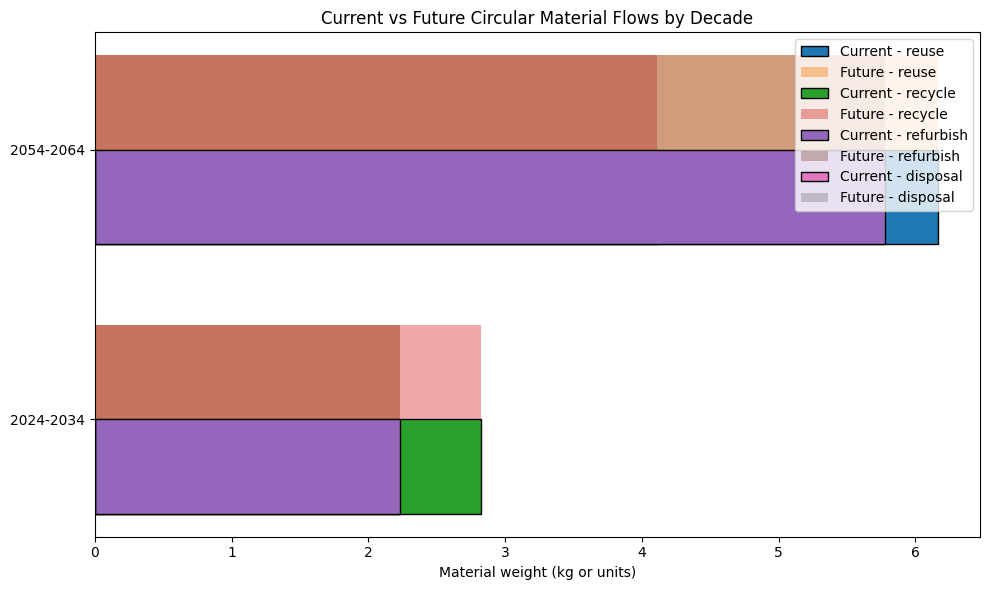

In [25]:
df_current = df
df_future = df_scenario

# Calculate end of life year and decade
def assign_decade(row):
    end_year = int(row['year_of_construction']) + 50
    if end_year < 2034:
        return '2024-2034'
    elif end_year < 2044:
        return '2034-2044'
    elif end_year < 2054:
        return '2044-2054'
    else:
        return '2054-2064'

df_current['decade'] = df_current.apply(assign_decade, axis=1)
df_future['decade'] = df_future.apply(assign_decade, axis=1)

# Function to compute total flow per category
def compute_flow(df):
    flows = df.copy()
    flow_records = []
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        grouped = flows.groupby('decade').apply(lambda x: (x['material_weight'] * x[category]).sum()).reset_index()
        grouped.columns = ['decade', category]
        flow_records.append(grouped.set_index('decade'))
    return pd.concat(flow_records, axis=1)

flow_current = compute_flow(df_current)
flow_future = compute_flow(df_future)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
decades = flow_current.index.tolist()
x = range(len(decades))

for i, cat in enumerate(['reuse', 'recycle', 'refurbish', 'disposal']):
    ax.barh(
        [xi - width/2 for xi in x],
        flow_current[cat],
        height=width,
        label=f'Current - {cat}',

        edgecolor='black'
    )
    ax.barh(
        [xi + width/2 for xi in x],
        flow_future[cat],
        height=width,
        label=f'Future - {cat}',
        alpha=0.4
    )

ax.set_yticks(x)
ax.set_yticklabels(decades)
ax.set_xlabel("Material weight (kg or units)")
ax.set_title("Current vs Future Circular Material Flows by Decade")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
